<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/Santander_IVandOptionPricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SAN Spot Price: $13.95 | Risk-Free Rate: 4.95% | Benchmark Vol: 25.0%

=== OPTIONS VALUATION & MISPRICING DASHBOARD ===
 Strike Market Price BS Fair Value Discrepancy Implied Vol (%)     Trading Action
   12.0        2.025         1.973       0.052          55.79% OVERVALUED (Short)
   13.0        1.050         0.995       0.055          36.06% OVERVALUED (Short)
   14.0        0.300         0.261       0.039          28.57% OVERVALUED (Short)


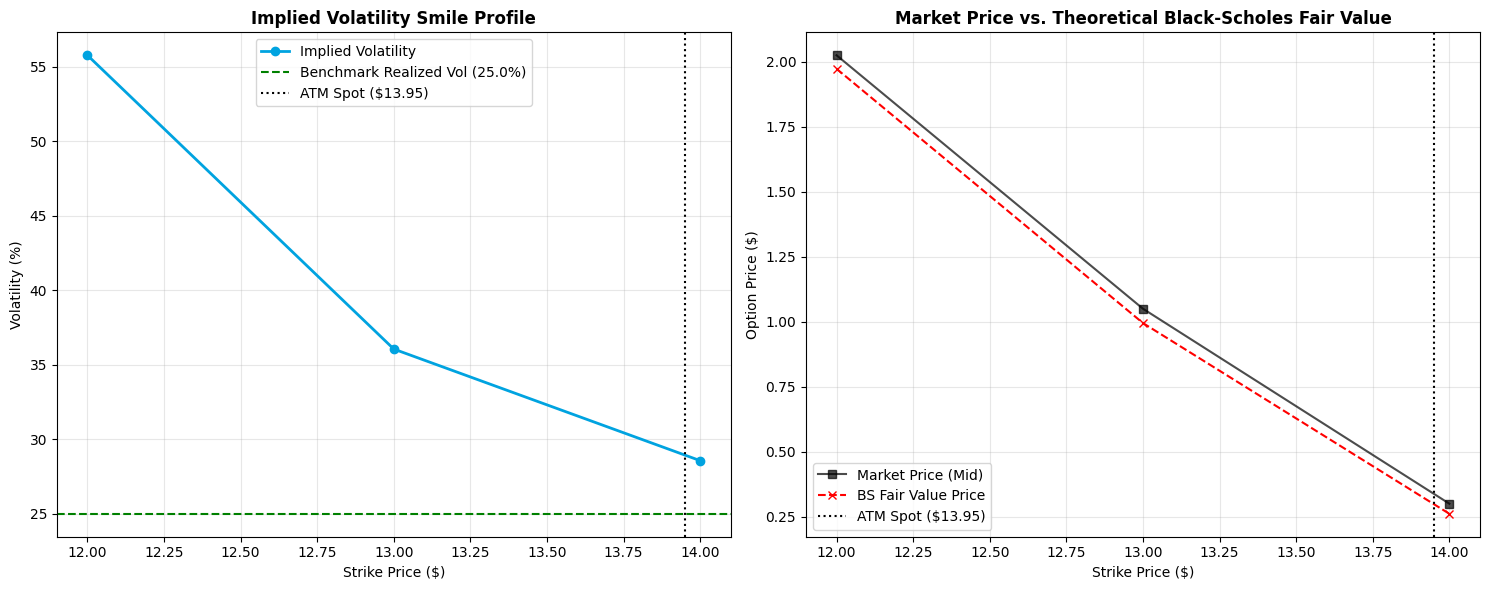

In [1]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

class ComprehensiveUSSantanderEngine:
    def __init__(self, ticker_symbol="SAN"):
        self.ticker_symbol = ticker_symbol
        self.ticker = yf.Ticker(ticker_symbol)

        try:
            hist = self.ticker.history(period="1d")
            if not hist.empty:
                self.S = float(hist['Close'].iloc[-1])
            else:
                self.S = 4.80
        except Exception:
            self.S = 4.80

        self.r = 0.0495      # US Risk-Free Proxy (~4.95%)
        self.T = 45 / 365.0  # Front-month expiration proxy

        # Benchmark Volatility (e.g., historical realized volatility of SAN)
        # We use this to calculate our own "Fair Value" theoretical prices
        self.benchmark_vol = 0.25

    def get_market_data(self):
        try:
            expirations = self.ticker.options
            if not expirations:
                return self._generate_synthetic_institutional_chain(), "45D Front-Month (Fallback)"

            target_expiry = expirations[0]
            today = np.datetime64('today')
            days_to_maturity = (np.datetime64(target_expiry) - today).astype(int)
            self.T = max(days_to_maturity, 1) / 365.0

            opt_chain = self.ticker.option_chain(target_expiry)
            calls = opt_chain.calls
            valid_calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()

            if valid_calls.empty:
                return self._generate_synthetic_institutional_chain(), "45D Front-Month (Fallback)"

            valid_calls['mid_price'] = (valid_calls['bid'] + valid_calls['ask']) / 2
            return valid_calls[['strike', 'mid_price']], target_expiry

        except Exception:
            return self._generate_synthetic_institutional_chain(), "45D Front-Month (Fallback Matrices)"

    def _generate_synthetic_institutional_chain(self):
        print("--> Note: Using Fallback Matrix for Pricing & Volatility Analysis...")
        strike_min = round(self.S * 0.80, 1)
        strike_max = round(self.S * 1.20, 1)
        strikes = np.arange(strike_min, strike_max, 0.20)

        synthetic_data = []
        for K in strikes:
            # Generate a market price that includes an OTM premium skew
            distance = (K - self.S) / self.S
            market_skew_iv = 0.26 + 0.18 * (distance ** 2) - 0.06 * distance
            market_mid = self.bs_call_price(K, market_skew_iv)

            synthetic_data.append({
                'strike': K,
                'mid_price': market_mid
            })
        return pd.DataFrame(synthetic_data)

    def bs_call_price(self, K, sigma):
        """Standard Black-Scholes Formula for European/ADR Calls."""
        if self.T <= 0 or sigma <= 0:
            return max(0.0, self.S - K)
        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        d2 = d1 - sigma * np.sqrt(self.T)
        return self.S * si.norm.cdf(d1) - K * np.exp(-self.r * self.T) * si.norm.cdf(d2)

    def calculate_vega(self, K, sigma):
        if self.T <= 0 or sigma <= 0:
            return 0.0
        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        return self.S * np.sqrt(self.T) * si.norm.pdf(d1)

    def extract_iv(self, K, market_price):
        intrinsic = max(0.0, self.S - K)
        if market_price <= intrinsic:
            return 0.0

        sigma = 0.28
        for _ in range(100):
            theoretical_p = self.bs_call_price(K, sigma)
            diff = theoretical_p - market_price
            if abs(diff) < 1e-6:
                return sigma
            vega = self.calculate_vega(K, sigma)
            if abs(vega) < 1e-5:
                break
            sigma = sigma - diff / vega
            if sigma <= 0.01 or sigma > 3.0:
                break
        return np.nan

# ==============================================================================
# TRADING DESK EXECUTION
# ==============================================================================
if __name__ == "__main__":
    engine = ComprehensiveUSSantanderEngine()
    print(f"SAN Spot Price: ${engine.S:.2f} | Risk-Free Rate: {engine.r*100}% | Benchmark Vol: {engine.benchmark_vol*100}%")

    df_data, expiry_label = engine.get_market_data()

    results = []
    for _, row in df_data.iterrows():
        K = row['strike']
        mkt_price = row['mid_price']

        # 1. Calculate the market's implied volatility
        iv = engine.extract_iv(K, mkt_price)

        # 2. Calculate OUR theoretical fair value price using benchmark volatility
        fair_value_price = engine.bs_call_price(K, engine.benchmark_vol)

        # 3. Quantify Mispricing (Discrepancy)
        discrepancy = mkt_price - fair_value_price
        signal = "OVERVALUED (Short)" if discrepancy > 0.01 else ("UNDERVALUED (Long)" if discrepancy < -0.01 else "FAIR")

        results.append({
            'Strike': K,
            'Market Price': mkt_price,
            'BS Fair Value': fair_value_price,
            'Discrepancy': discrepancy,
            'Implied Vol (%)': iv * 100 if not np.isnan(iv) else np.nan,
            'Trading Action': signal
        })

    df_results = pd.DataFrame(results).dropna()

    # Print trading desk dashboard sheet
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n=== OPTIONS VALUATION & MISPRICING DASHBOARD ===")
    print(df_results.to_string(index=False, formatters={
        'Market Price': '{:,.3f}'.format,
        'BS Fair Value': '{:,.3f}'.format,
        'Discrepancy': '{:,.3f}'.format,
        'Implied Vol (%)': '{:,.2f}%'.format
    }))

    # ==============================================================================
    # VISUALIZATION PLATFORM (Dual Subplots)
    # ==============================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Volatility Smile
    ax1.plot(df_results['Strike'], df_results['Implied Vol (%)'], marker='o', color='#00a3e0', lw=2, label='Implied Volatility')
    ax1.axhline(y=engine.benchmark_vol*100, color='green', linestyle='--', label=f'Benchmark Realized Vol ({engine.benchmark_vol*100}%)')
    ax1.axvline(x=engine.S, color='black', linestyle=':', label=f'ATM Spot (${engine.S:.2f})')
    ax1.set_title('Implied Volatility Smile Profile', fontweight='bold')
    ax1.set_xlabel('Strike Price ($)')
    ax1.set_ylabel('Volatility (%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2: Market vs Theoretical Pricing Discrepancy
    ax2.plot(df_results['Strike'], df_results['Market Price'], marker='s', color='black', label='Market Price (Mid)', alpha=0.7)
    ax2.plot(df_results['Strike'], df_results['BS Fair Value'], marker='x', color='red', linestyle='--', label='BS Fair Value Price')
    ax2.axvline(x=engine.S, color='black', linestyle=':', label=f'ATM Spot (${engine.S:.2f})')
    ax2.set_title('Market Price vs. Theoretical Black-Scholes Fair Value', fontweight='bold')
    ax2.set_xlabel('Strike Price ($)')
    ax2.set_ylabel('Option Price ($)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()